In [73]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [74]:
datos = pd.read_csv("./data/superstore_dataset2012.csv")

datos.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,21896,ID-2012-71858,1/2/2012,7/2/2012,Standard Class,CP-12085,Cathy Prescott,Corporate,Jakarta,Jakarta,...,TEC-PH-10003784,Technology,Phones,"Motorola Signal Booster, with Caller ID",593.9895,5,0.17,-71.7105,52.22,Medium
1,4323,MX-2012-154459,1/2/2012,6/2/2012,Standard Class,JF-15190,Jamie Frazer,Consumer,Santiago,Santiago,...,TEC-PH-10002102,Technology,Phones,"Nokia Headset, Cordless",151.9200,3,0.00,71.4000,32.94,High
2,2829,MX-2012-114461,1/2/2012,5/2/2012,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla,...,TEC-AC-10002760,Technology,Accessories,"Memorex Memory Card, Erganomic",200.1600,3,0.00,0.0000,28.95,High
3,2828,MX-2012-114461,1/2/2012,5/2/2012,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla,...,FUR-CH-10001423,Furniture,Chairs,"Harbour Creations Rocking Chair, Black",192.8800,2,0.00,54.0000,19.27,High
4,6762,MX-2012-151904,1/2/2012,3/2/2012,First Class,DJ-13420,Denny Joy,Corporate,Villa Canales,Guatemala,...,OFF-PA-10003571,Office Supplies,Paper,"Enermax Cards & Envelopes, Recycled",94.0200,3,0.00,1.8600,10.73,Medium
5,2827,MX-2012-114461,1/2/2012,5/2/2012,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla,...,OFF-SU-10001750,Office Supplies,Supplies,"Stiletto Trimmer, High Speed",57.0000,2,0.00,24.4800,9.51,High
6,47271,NI-2012-390,1/2/2012,5/2/2012,Standard Class,PP-8955,Paul Prost,Home Office,Maiduguri,Borno,...,TEC-CAN-10000030,Technology,Copiers,"Canon Fax Machine, Laser",95.5170,1,0.70,-191.0430,8.07,Medium
7,21897,ID-2012-71858,1/2/2012,7/2/2012,Standard Class,CP-12085,Cathy Prescott,Corporate,Jakarta,Jakarta,...,FUR-CH-10004576,Furniture,Chairs,"Hon Bag Chairs, Adjustable",69.5544,2,0.27,-2.8656,5.83,Medium
8,15611,ES-2012-2785188,1/2/2012,6/2/2012,Standard Class,RA-19945,Ryan Akin,Consumer,Fiumicino,Lazio,...,TEC-AC-10000494,Technology,Accessories,"Logitech Numeric Keypad, USB",139.5900,3,0.00,59.9400,5.45,Medium
9,46486,BO-2012-7240,1/2/2012,5/2/2012,Standard Class,BT-1305,Beth Thompson,Home Office,Pinsk,Brest,...,OFF-SME-10004160,Office Supplies,Storage,"Smead Folders, Wire Frame",33.1200,2,0.00,1.9800,2.46,Medium


In [75]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4246 entries, 0 to 4245
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          4246 non-null   int64  
 1   Order ID        4246 non-null   object 
 2   Order Date      4246 non-null   object 
 3   Ship Date       4246 non-null   object 
 4   Ship Mode       4246 non-null   object 
 5   Customer ID     4246 non-null   object 
 6   Customer Name   4246 non-null   object 
 7   Segment         4246 non-null   object 
 8   City            4246 non-null   object 
 9   State           4246 non-null   object 
 10  Country         4246 non-null   object 
 11  Postal Code     823 non-null    float64
 12  Market          4246 non-null   object 
 13  Region          4246 non-null   object 
 14  Product ID      4246 non-null   object 
 15  Category        4246 non-null   object 
 16  Sub-Category    4246 non-null   object 
 17  Product Name    4246 non-null   o

In [76]:
# Esto te muestra cuántos valores NO nulos tiene cada país en Postal Code
cobertura = datos.groupby('Country')['Postal Code'].count()
print(cobertura.sort_values(ascending=False))

Country
United States    823
Afghanistan        0
Netherlands        0
Poland             0
Philippines        0
                ... 
France             0
Finland            0
El Salvador        0
Egypt              0
Zimbabwe           0
Name: Postal Code, Length: 112, dtype: int64


In [77]:
datos["Order Date"] = pd.to_datetime(datos["Order Date"])
datos["Ship Date"] = pd.to_datetime(datos["Ship Date"], format='mixed', dayfirst=True)
datos["Postal Code"] = datos["Postal Code"].astype(str)

In [78]:
datos.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Shipping Cost
count,4246.000000,4246,4246,4246.000000,4246.000000,4246.000000,4246.000000,4246.000000
mean,25248.240226,2012-06-23 23:10:29.109750272,2012-07-28 17:09:58.586905600,237.029481,3.444183,0.146615,27.698282,24.539708
min,66.000000,2012-01-02 00:00:00,2012-01-03 00:00:00,1.112000,1.000000,0.000000,-1806.240000,0.030000
25%,12424.250000,2012-04-01 00:00:00,2012-05-13 00:00:00,30.564000,2.000000,0.000000,-0.062700,2.610000
50%,24848.000000,2012-06-12 00:00:00,2012-08-11 00:00:00,82.527900,3.000000,0.000000,9.029400,7.600000
75%,37522.750000,2012-10-02 00:00:00,2012-10-17 00:00:00,245.814750,5.000000,0.200000,35.902500,23.530000
max,51289.000000,2012-12-12 00:00:00,2012-12-19 00:00:00,5759.964000,14.000000,0.800000,2229.024000,759.470000
std,14711.393243,NaN,NaN,426.974969,2.228431,0.216120,147.459878,50.422150


In [79]:
# Calcular Q1 (percentil 25) y Q3 (percentil 75)
Q1 = datos['Sales'].quantile(0.25)
Q3 = datos['Sales'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR = Q3 - Q1

# Definir límites (típicamente 1.5 veces el IQR)
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar los outliers
outliers = datos[(datos['Sales'] < limite_inferior) | (datos['Sales'] > limite_superior)]

print(f"Límite superior para ser outlier: {limite_superior:.2f}")
print(f"Cantidad de outliers detectados: {len(outliers)}")
print(f"Venta más alta detectada: {outliers['Sales'].max()}")

Límite superior para ser outlier: 568.69
Cantidad de outliers detectados: 476
Venta más alta detectada: 5759.964


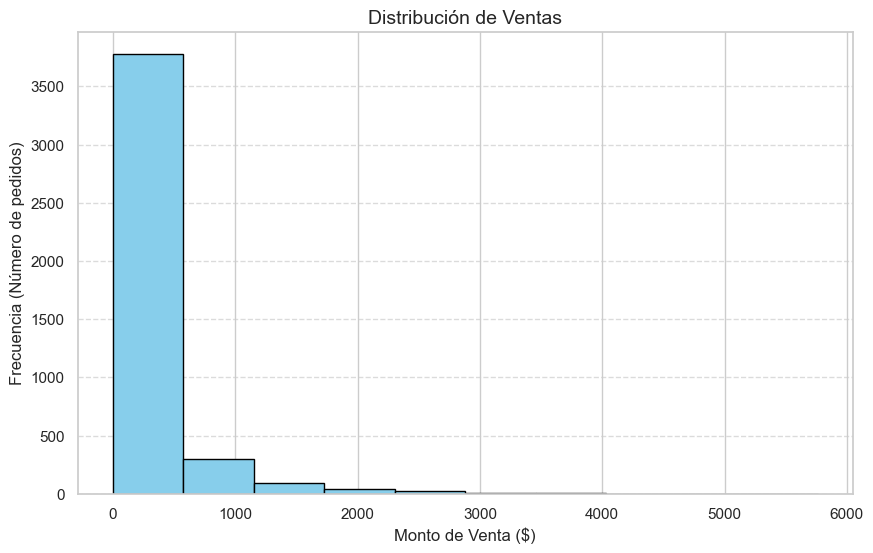

In [80]:
import matplotlib.pyplot as plt

# Crear la figura
plt.figure(figsize=(10, 6))

# Dibujar histograma
plt.hist(datos['Sales'], bins=10, color='skyblue', edgecolor='black')

# Personalización
plt.title('Distribución de Ventas', fontsize=14)
plt.xlabel('Monto de Venta ($)', fontsize=12)
plt.ylabel('Frecuencia (Número de pedidos)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

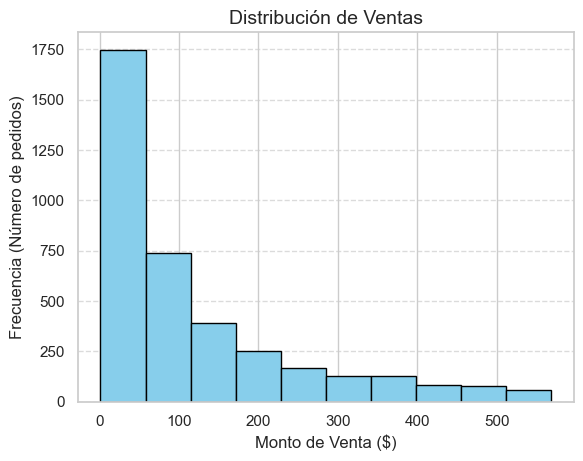

In [89]:
df_filtrado = datos[datos['Sales'] <= limite_superior]

# Dibujar histograma
plt.hist(df_filtrado['Sales'], bins=10, color='skyblue', edgecolor='black')

# Personalización
plt.title('Distribución de Ventas', fontsize=14)
plt.xlabel('Monto de Venta ($)', fontsize=12)
plt.ylabel('Frecuencia (Número de pedidos)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

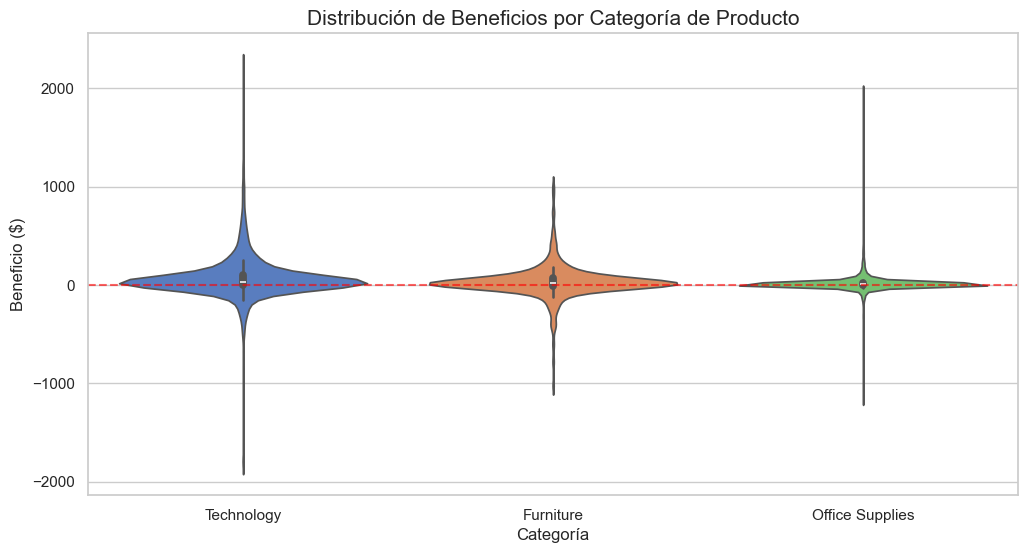

In [82]:
import seaborn as sns

sns.set_theme(style="whitegrid")

# Crear el gráfico de violín
plt.figure(figsize=(12, 6))
sns.violinplot(data=datos, x='Category', y='Profit', hue='Category', palette='muted', legend=False)

# Añadir una línea en 0 para identificar ganancias vs pérdidas
plt.axhline(0, color='red', linestyle='--', alpha=0.6)

# 5. Personalización
plt.title('Distribución de Beneficios por Categoría de Producto', fontsize=15)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Beneficio ($)', fontsize=12)

plt.show()

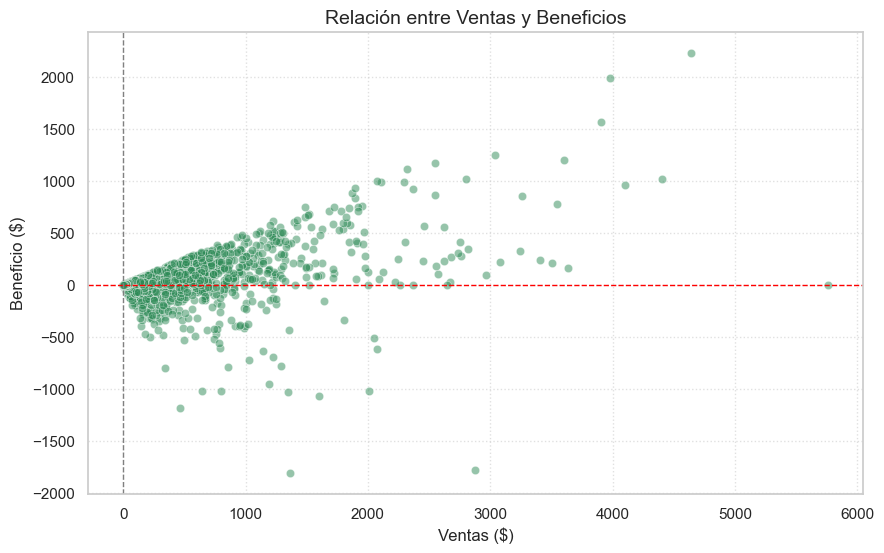

In [83]:
# Crear la figura
plt.figure(figsize=(10, 6))

# Dibujar el scatter plot
plt.scatter(datos['Sales'], datos['Profit'], alpha=0.5, c='seagreen', edgecolors='white', linewidth=0.5)

# Añadir líneas de referencia en 0 para identificar ganancias y pérdidas claramente
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Línea de beneficio 0
plt.axvline(0, color='gray', linestyle='--', linewidth=1) # Línea de ventas 0

# Personalización
plt.title('Relación entre Ventas y Beneficios', fontsize=14)
plt.xlabel('Ventas ($)', fontsize=12)
plt.ylabel('Beneficio ($)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

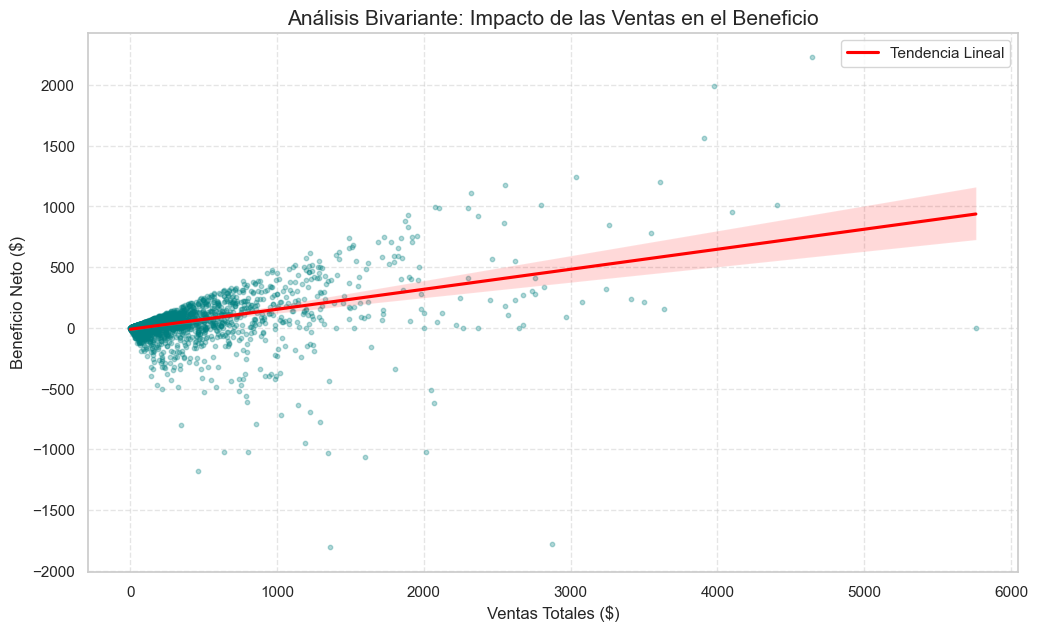

In [84]:
plt.figure(figsize=(12, 7))

# 3. Crear el regplot
# Usamos 'scatter_kws' para hacer los puntos más pequeños y transparentes
# Usamos 'line_kws' para resaltar la línea de regresión en un color contrastante
sns.regplot(data=datos, x='Sales', y='Profit', 
            scatter_kws={'alpha':0.3, 's':10, 'color':'teal'}, 
            line_kws={'color':'red', 'label':'Tendencia Lineal'})

# 4. Personalización técnica
plt.title('Análisis Bivariante: Impacto de las Ventas en el Beneficio', fontsize=15)
plt.xlabel('Ventas Totales ($)', fontsize=12)
plt.ylabel('Beneficio Neto ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

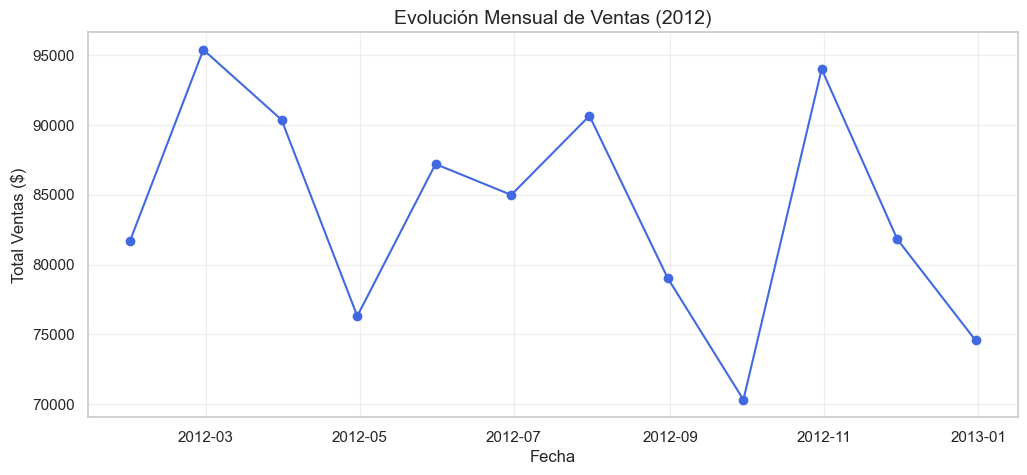

In [85]:
# Agrupar ventas por mes
ventas_mensuales = datos.resample('M', on='Order Date')['Sales'].sum()

# Graficar
plt.figure(figsize=(12, 5))
plt.plot(ventas_mensuales.index, ventas_mensuales.values, marker='o', linestyle='-', color='royalblue')

plt.title('Evolución Mensual de Ventas (2012)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Total Ventas ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

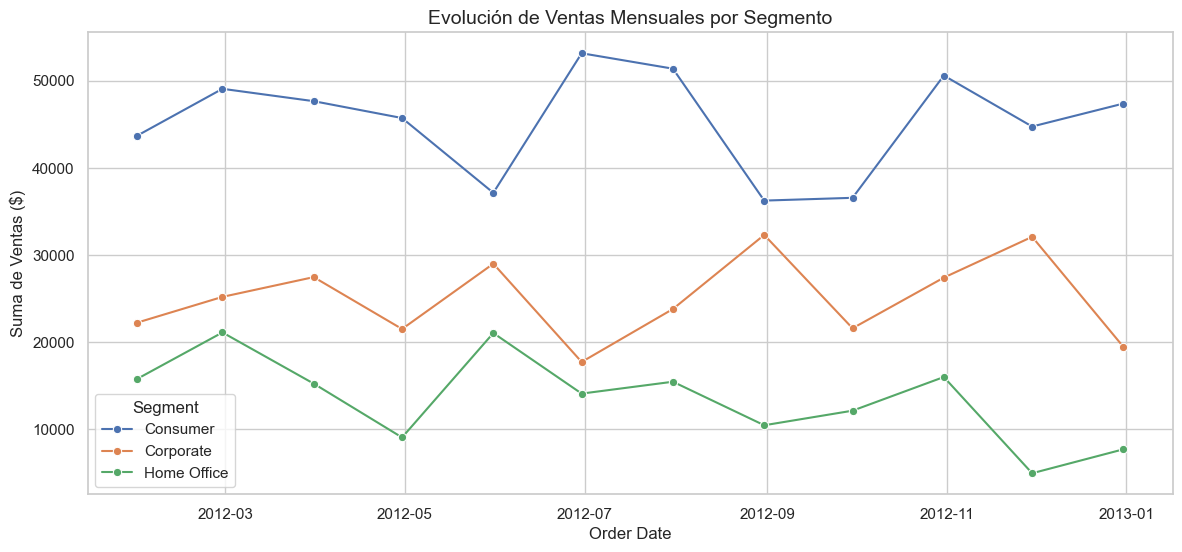

In [86]:
datos_resampled = datos.set_index('Order Date').groupby([pd.Grouper(freq='M'), 'Segment'])['Sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=datos_resampled, x='Order Date', y='Sales', hue='Segment', marker='o')

plt.title('Evolución de Ventas Mensuales por Segmento', fontsize=14)
plt.ylabel('Suma de Ventas ($)')
plt.show()

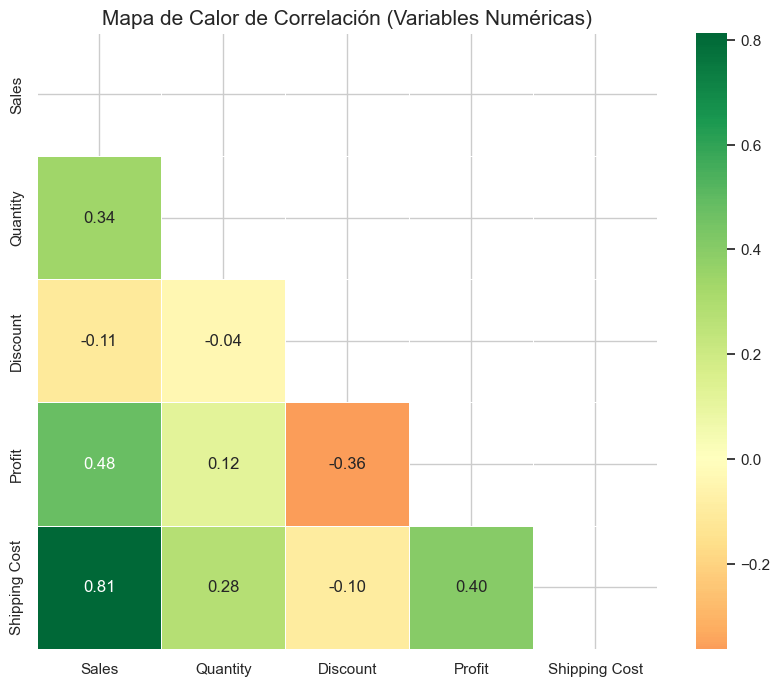

In [87]:
import numpy as np 

# Seleccionar solo las columnas numéricas relevantes
cols_numericas = datos[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']]

# Calcular la matriz de correlación
corr_matrix = cols_numericas.corr()

plt.figure(figsize=(10, 8))

mask = np.zeros_like(corr_matrix)
mask[np.triu_indices_from(mask)] = True

# Crear el heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlGn', center=0, fmt=".2f", linewidths=0.5)

plt.title('Mapa de Calor de Correlación (Variables Numéricas)', fontsize=15)
plt.show()

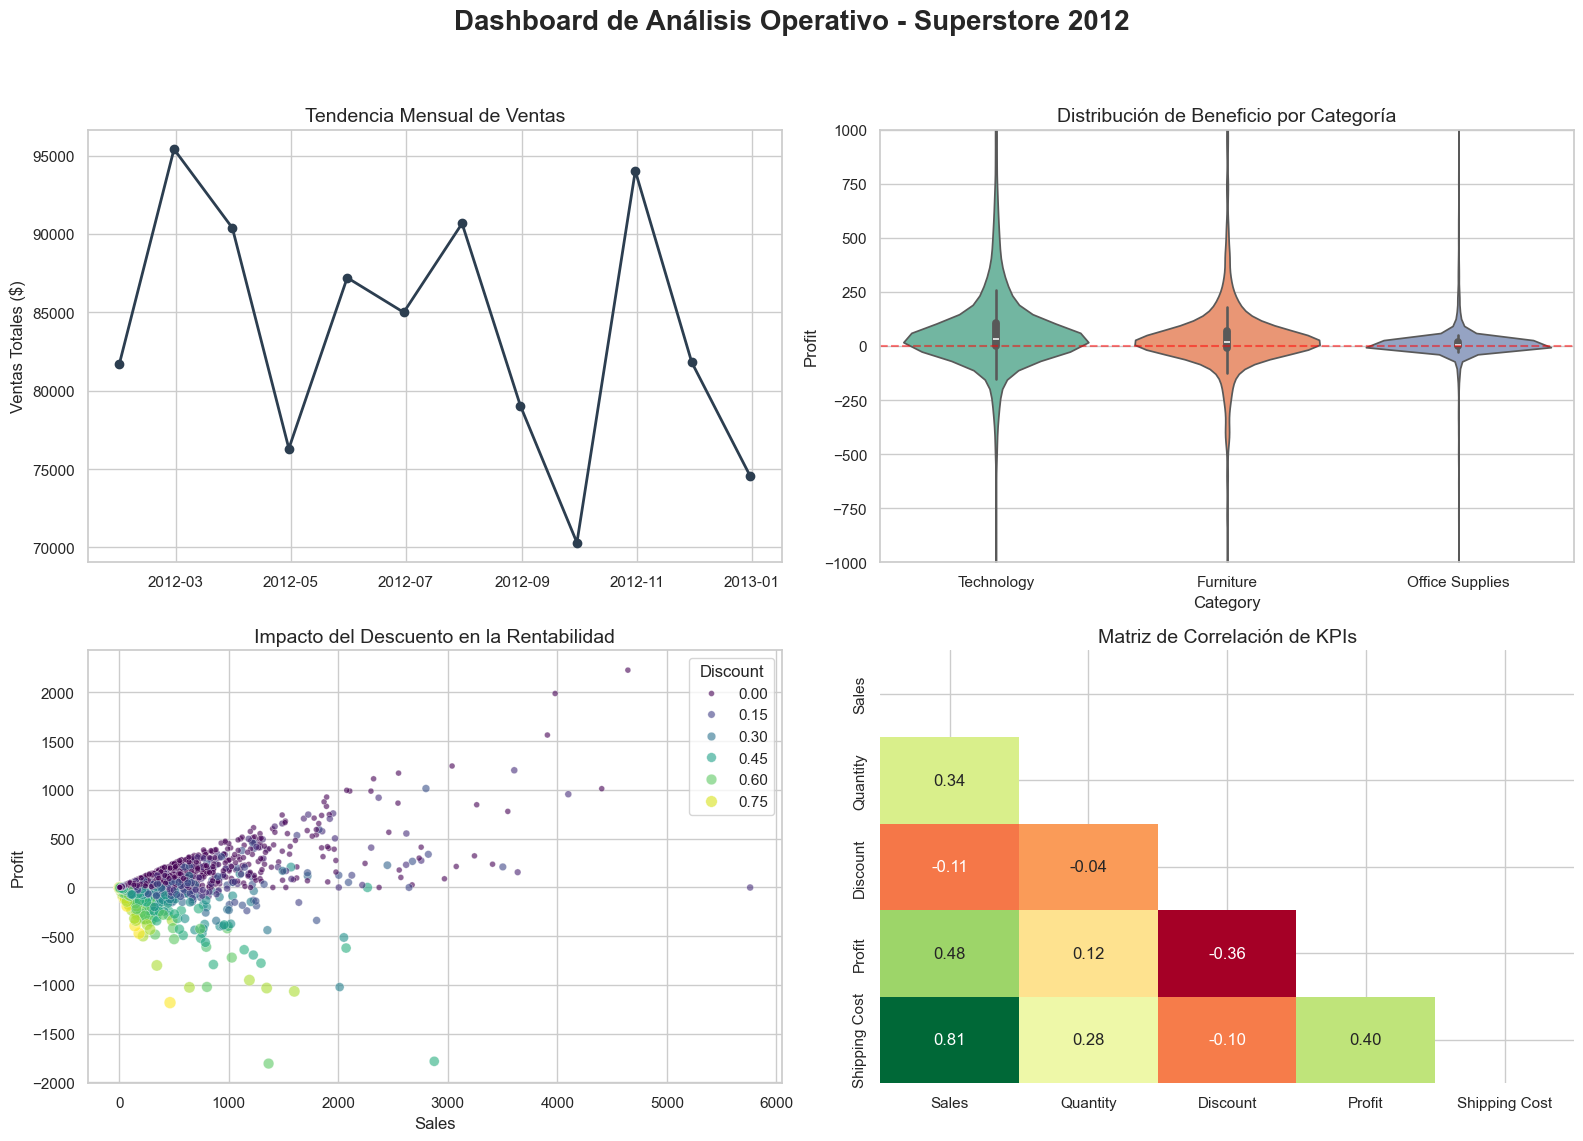

In [88]:
# Configuración de estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Dashboard de Análisis Operativo - Superstore 2012', fontsize=20, fontweight='bold')

# --- SUBPLOT 1: Evolución Temporal (Líneas) ---
ventas_mes = datos.resample('M', on='Order Date')['Sales'].sum()
axes[0, 0].plot(ventas_mes.index, ventas_mes.values, marker='o', color='#2c3e50', linewidth=2)
axes[0, 0].set_title('Tendencia Mensual de Ventas', fontsize=14)
axes[0, 0].set_ylabel('Ventas Totales ($)')

# --- SUBPLOT 2: Distribución de Ganancias (Violin Plot) ---
sns.violinplot(data=datos, x='Category', y='Profit', ax=axes[0, 1], palette='Set2', hue='Category', legend=False)
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_title('Distribución de Beneficio por Categoría', fontsize=14)
axes[0, 1].set_ylim(-1000, 1000) # Limitamos para ver mejor el cuerpo

# --- SUBPLOT 3: Relación Ventas vs Descuento (Scatter Plot) ---
sns.scatterplot(data=datos, x='Sales', y='Profit', hue='Discount', size='Discount', 
                ax=axes[1, 0], palette='viridis', alpha=0.6)
axes[1, 0].set_title('Impacto del Descuento en la Rentabilidad', fontsize=14)

# --- SUBPLOT 4: Correlación de Variables (Heatmap) ---
corr = datos[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']].corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, annot=True, cmap='RdYlGn', ax=axes[1, 1], cbar=False, fmt=".2f")
axes[1, 1].set_title('Matriz de Correlación de KPIs', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('analisis_superstore_2012.png', dpi=300, bbox_inches='tight')
plt.show()